# Measurement x=15, y=0, z=0

### Merged Notebook: PDM, c-PDM, LR-PDM, and ESN-Ridge Analysis

This notebook provides a fair comparison between several methods for predicting velocity from potential measurements. The ESN method has been updated to not use a moving average, and all models are evaluated on the same test data slice (excluding the ESN warmup period) for a fair comparison.

### Imports

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

from scipy.stats import randint, uniform, loguniform

import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge, Input

from ppvm_py.utils import load_object
from ppvm_py.yz_slice_utils import find_closest_coordinate_index
from ppvm_py.plotting import plot_timeseries
from ppvm_py.data_processing.yz_slice import print_yz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map
from ppvm_py.feature_generation.sdc import symmetric_difference_coefficient
from ppvm_py.feature_generation.pdm import pdm_approximated_velocity

### General Args

In [2]:
random_seed = 4629837

# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    # Path for Ha=300 data
    slice_folder_path = Path("../../../../data/re1000_ha300/SliceYZ_x0015/")
elif Ha == 1000:
    # Path for Ha=1000 data
    slice_folder_path = Path("../../../../data/re1000_ha1000/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

test_size = 0.3
n_warmup_test = 100 # Warmup period for ESN, also excluded from other models' MSE for fairness.

i_test_plot_end = 1000

### Preamble

In [3]:
mses = {}  # Dict for gathering mean-squared-errors.
np.random.seed(random_seed)

### Load Data

In [4]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [5]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = create_index_to_coord_map(gradF_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(gradF_data)

Object successfully loaded from C:\Users\hydro\Documents\phd\nuclear_fusion_cooling\data\re1000_ha300\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.027423e-01  0.000000e+00
  0.000000e+00 -5.862112e-04  1.594463e+00]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.175437e-01  0.000000e+00
 -4.764620e-01 -5.860972e-04  1.599692e+00]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.220912e-01  2.072063e+00
  0.000000e+00 -5.841985e-04  1.580085e+00]
  (y=-0.99, z=-0.99): [ 2.256158e+00 -1.132797e-01  1.513446e-02 -2.226841e-01 -5.704941e-02
 -3.949543e-01 -5.842091e-04  1.584242e+00]

Object successfully loaded from C:\Users\hydro\

### Get Existing x and y Coordinates

In [6]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
)
output_indices = (
    slice(None),
    i_y_center,
    i_z_center,
)

### Define Train and Test Set

In [7]:
fld_data_train, fld_data_test = train_test_split(
    fld_data['timeseries'],
    test_size=test_size,
    shuffle=False,
)

# train
output_indices_shape_train = fld_data_train[output_indices].shape[:-1]
n_output_indices_train = int(np.prod(list(output_indices_shape_train)))

# test
output_indices_shape_test = fld_data_test[output_indices].shape[:-1]
n_output_indices_test = int(np.prod(list(output_indices_shape_test)))

n_time_output_indices_test = output_indices_shape_test[0]
n_spatial_output_indices_test = int(np.prod(output_indices_shape_test[1:]))

### Define and Scale $y_{\text{true}}$ and Input $\phi$

These are the global targets and features. They are scaled once and used for all applicable models to ensure consistency.

In [8]:
# --- Define and Scale y_true --- 
# train
y_true_train_unscaled = fld_data_train[
    ...,
    fld_data['labels'].index('vx'),
]

# Train SS on all training data to make it comparable to other output_indices.
ss_y_true = StandardScaler()
ss_y_true.fit(y_true_train_unscaled.reshape(-1, 1))

y_true_train = y_true_train_unscaled[output_indices]
y_true_train = ss_y_true.transform(
    y_true_train.reshape(-1, 1),
).reshape(*output_indices_shape_train)

# test
y_true_test_unscaled = fld_data_test[
    ...,
    fld_data['labels'].index('vx'),
]
y_true_test = y_true_test_unscaled[output_indices]
y_true_test = ss_y_true.transform(
    y_true_test.reshape(-1, 1),
).reshape(*output_indices_shape_test)

# --- Define and Scale phi ---
# train
phi_train_unscaled = fld_data_train[
    ...,
    fld_data['labels'].index('F'),
]
ss_phi = StandardScaler()
ss_phi.fit(phi_train_unscaled.reshape(-1, 1))

shape_ = phi_train_unscaled.shape
phi_train = ss_phi.transform(phi_train_unscaled.reshape(-1, 1)).reshape(shape_)

# test
phi_test_unscaled = fld_data_test[
    ...,
    fld_data['labels'].index('F'),
]
shape_ = phi_test_unscaled.shape
phi_test = ss_phi.transform(phi_test_unscaled.reshape(-1, 1)).reshape(shape_)

---
## Section 1: PDM and Linear Methods
---

### General Benchmark

Assuming we know $j_y$ and the measurement distance of potentials can be infinitesimal small, we can use the partial derivative $\frac{\partial{\phi}}{\partial{y}}$ of the potential. With this, we can calculate the $v_x$ exactly using Ohm's law. The remainder is simulation error.

This error is taken as benchmark to compare all methods against.

mse(part + j) = 0.02579092683066761


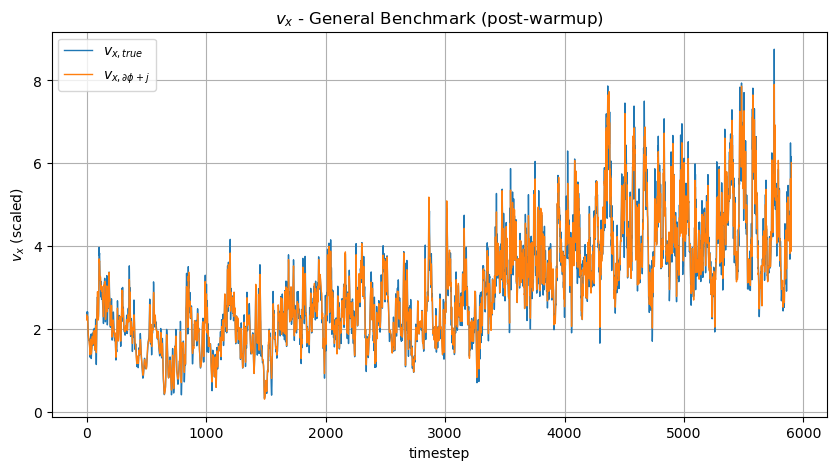

In [9]:
part_phi_y = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdy'):gradF_data['labels'].index('dfdy') + 1,
    ]
j_y_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jy'):fld_data['labels'].index('jy') + 1,
    ]

_, part_phi_y_test, _, j_y_center_test = train_test_split(
    part_phi_y,
    j_y_center,
    test_size=test_size,
    shuffle=False,
    )
v_x_ohms_law_test = (part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_ohms_law_test = ss_y_true.transform(
    v_x_ohms_law_test,
    copy=True,
    )

# Calculate MSE on the test set minus the warmup period for fair comparison
mse_ohms_law = mean_squared_error(y_true_test[n_warmup_test:], y_pred_ohms_law_test[n_warmup_test:])
mses['General Benchmark'] = mse_ohms_law
print(f"mse(part + j) = {mse_ohms_law}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_ohms_law_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, \\partial{\\phi} + j}$",
    ],
    title="$v_x$ - General Benchmark (post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

### Potential Difference Method (SDC) Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. This is also called *Potential Difference Method*. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Define Points $y_1$ and $y_2$ for PDM

In [10]:
"""Coordinates by using delta_i
"""

delta_i = 1

i_y_1_y = i_y_center - delta_i
i_y_1_z = i_z_center

i_y_2_y = i_y_center + delta_i
i_y_2_z = i_z_center

y_1_y, y_1_z = fld_data['index_to_coord_map'][i_y_1_y, i_y_1_z]
y_2_y, y_2_z = fld_data['index_to_coord_map'][i_y_2_y, i_y_2_z]

In [11]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_data['index_to_coord_map'][i_y_center, i_z_center][0]}, z = {fld_data['index_to_coord_map'][i_y_center, i_z_center][1]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_1 = {y_1_y - y_coord}, delta_z^y_1 = {y_1_z - z_coord}, ", end='')
print(f"delta_i_y^y_1 = {i_y_1_y - i_y_center}, delta_i_z^y_1 = {i_y_1_z - i_z_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_2 = {y_2_y - y_coord}, delta_z^y_2 = {y_2_z - z_coord}, ", end='')
print(f"delta_i_y^y_2 = {i_y_2_y - i_y_center}, delta_i_z^y_2 = {i_y_2_z - i_z_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: ", end='')
print(f"delta_y = {delta_y}, delta_z = {delta_z}, ", end='')
print(f"delta_i_y = {i_y_2_y - i_y_1_y}, delta_i_z = {i_y_2_z - i_y_1_z}")

Center: y = -0.01842125, z = -0.01842125

y_1 Coordinates: y = -0.05560156, z = -0.01842125
Difference to center: delta_y^y_1 = -0.03718031, delta_z^y_1 = 0.0, delta_i_y^y_1 = -1, delta_i_z^y_1 = 0

y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i_y^y_2 = 1, delta_i_z^y_2 = 0

Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0, delta_i_y = 2, delta_i_z = 0


##### Plot Input Signals at Probe Points

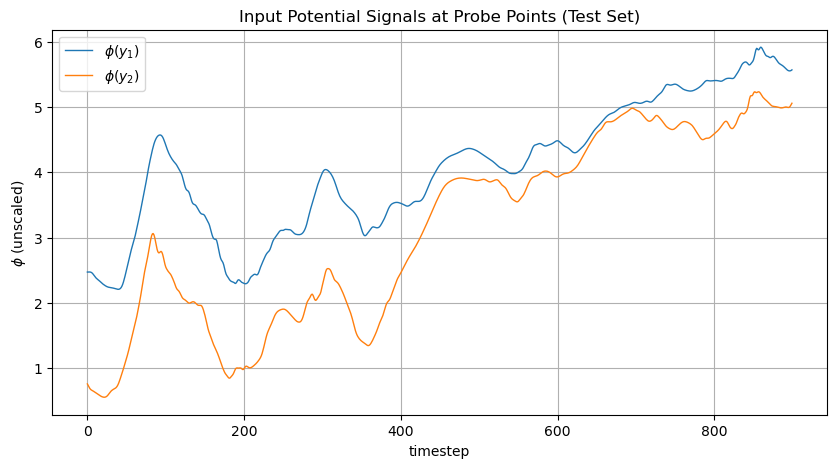

In [12]:
# Get unscaled phi values at the two probe points from the test set
phi_y_1_test_unscaled_plot = phi_test_unscaled[
    :,
    i_y_1_y,
    i_y_1_z,
].reshape(-1, 1)

phi_y_2_test_unscaled_plot = phi_test_unscaled[
    :,
    i_y_2_y,
    i_y_2_z,
].reshape(-1, 1)

# Plot the input signals
plot_timeseries(
    data_list=[
        phi_y_1_test_unscaled_plot[n_warmup_test:i_test_plot_end],
        phi_y_2_test_unscaled_plot[n_warmup_test:i_test_plot_end],
    ],
    labels=[
        "$\\phi(y_1)$",
        "$\\phi(y_2)$",
    ],
    title="Input Potential Signals at Probe Points (Test Set)",
    xlabel="timestep",
    ylabel="$\\phi$ (unscaled)",
)

##### Testing PDM Benchmark

mse(pdm_j) = 0.10540168895889483


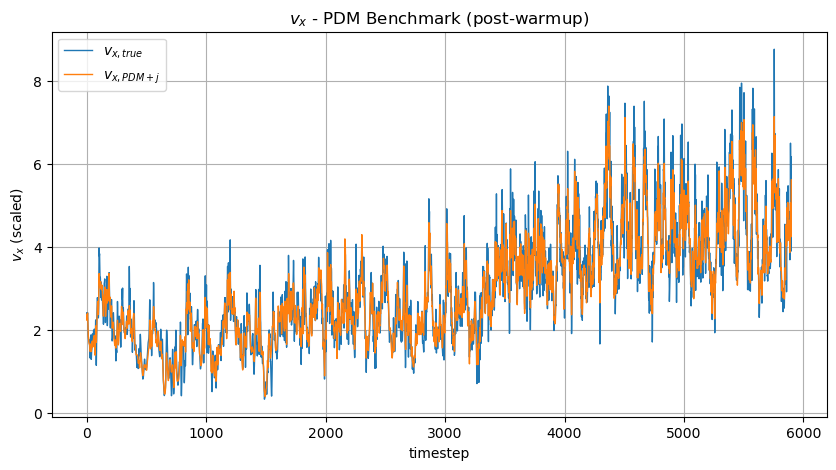

In [13]:
# Get scaled phi values at test points
phi_y_1_test = phi_test[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_test = phi_test[
    :,
    i_y_2_y,
    i_y_2_z,
]

# Calculate SDC
approx_part_phi_y_test = symmetric_difference_coefficient(
    former_point=ss_phi.inverse_transform(phi_y_1_test.reshape(-1, 1)),
    latter_point=ss_phi.inverse_transform(phi_y_2_test.reshape(-1, 1)),
    delta_l=delta_y,
).reshape(-1, 1)

# Calculate velocity and scale it
v_x_sdc_test = (approx_part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_sdc_test = ss_y_true.transform(
    v_x_sdc_test,
    copy=True,
)

# Calculate MSE on the test set minus the warmup period
mse_sdc = mean_squared_error(y_true_test[n_warmup_test:], y_pred_sdc_test[n_warmup_test:])
mses['PDM Benchmark'] = mse_sdc
print(f"mse(pdm_j) = {mse_sdc}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_sdc_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, PDM + j}$",
    ],
    title="$v_x$ - PDM Benchmark (post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

### Potential Difference Method (PDM)

mse(pdm) = 1.6918282139365575


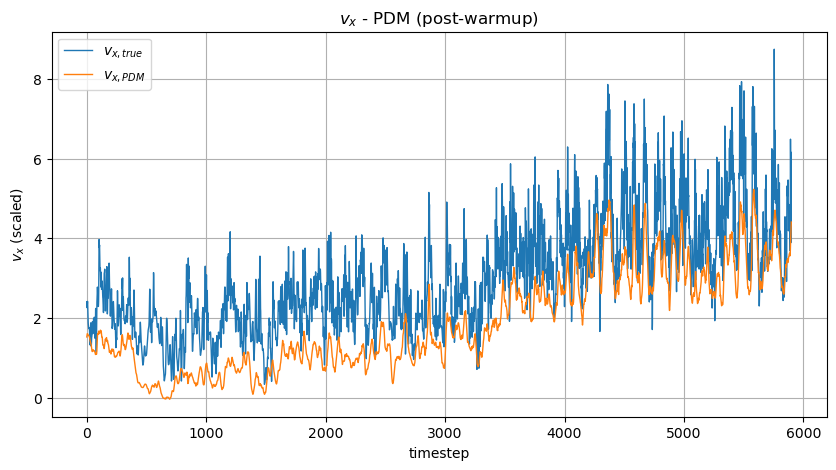

In [14]:
# Get unscaled phi values from the test set
phi_y_1_test_unscaled = phi_test_unscaled[
    :,
    i_y_1_y,
    i_y_1_z,
].reshape(-1, 1)

phi_y_2_test_unscaled = phi_test_unscaled[
    :,
    i_y_2_y,
    i_y_2_z,
].reshape(-1, 1)

# Calculate velocity
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test_unscaled,
    latter_point=phi_y_2_test_unscaled,
    delta_l=delta_y,
    B=B_z,
)

# Scale the prediction for comparison
y_pred_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=True,
)

# Calculate MSE on the test set minus the warmup period
mse_pdm = mean_squared_error(y_true_test[n_warmup_test:], y_pred_pdm_test[n_warmup_test:])
mses['PDM'] = mse_pdm
print(f"mse(pdm) = {mse_pdm}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_pdm_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, PDM}$",
    ],
    title="$v_x$ - PDM (post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

### Linear Scaled PDM (c-PDM)

Correction factor c = 0.6414303455686842
mse(c-PDM) = 0.9210589289423238


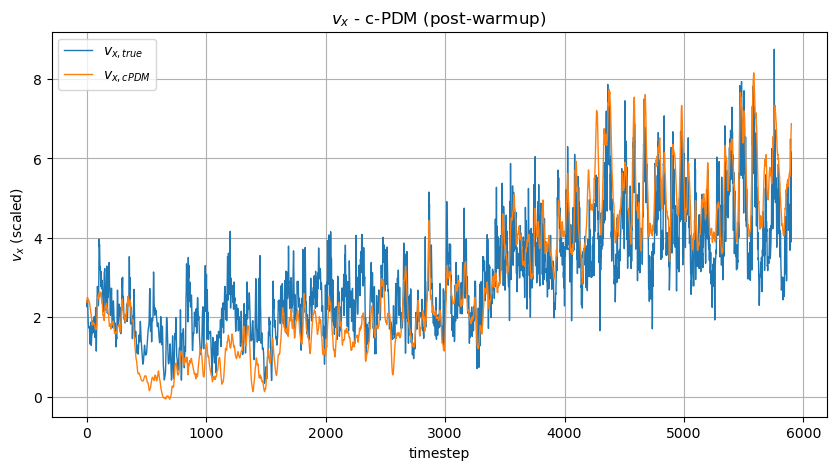

In [15]:
# --- Training ---
# Prepare training data (unscaled phi)
phi_y_1_train_unscaled = phi_train_unscaled[:, i_y_1_y, i_y_1_z].reshape(-1, 1)
phi_y_2_train_unscaled = phi_train_unscaled[:, i_y_2_y, i_y_2_z].reshape(-1, 1)

# Calculate PDM velocity on training data
v_x_pdm_train = pdm_approximated_velocity(
    former_point=phi_y_1_train_unscaled,
    latter_point=phi_y_2_train_unscaled,
    delta_l=delta_y,
    B=B_z,
)

# Scale the PDM feature for training
v_x_pdm_train_scaled = ss_y_true.transform(v_x_pdm_train, copy=True)

# Train a linear regression model without intercept to find the correction factor 'c'
model_cpdm = LinearRegression(fit_intercept=False)
model_cpdm.fit(X=v_x_pdm_train_scaled, y=y_true_train)
c = 1 / model_cpdm.coef_[0]
print(f"Correction factor c = {c}")

# --- Testing ---
# We already have v_x_pdm_test from the previous step. Scale it.
v_x_pdm_test_scaled = ss_y_true.transform(v_x_pdm_test, copy=True)

# Apply correction
y_pred_c_pdm_test = v_x_pdm_test_scaled / c

# Calculate MSE on the test set minus the warmup period
mse_c_pdm = mean_squared_error(y_true_test[n_warmup_test:], y_pred_c_pdm_test[n_warmup_test:])
mses['c-PDM'] = mse_c_pdm
print(f"mse(c-PDM) = {mse_c_pdm}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_c_pdm_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, cPDM}$",
    ],
    title="$v_x$ - c-PDM (post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

### Linear Regression on Feature: PDM (LR-PDM)

mse(LR-PDM) = 0.6678755588138511


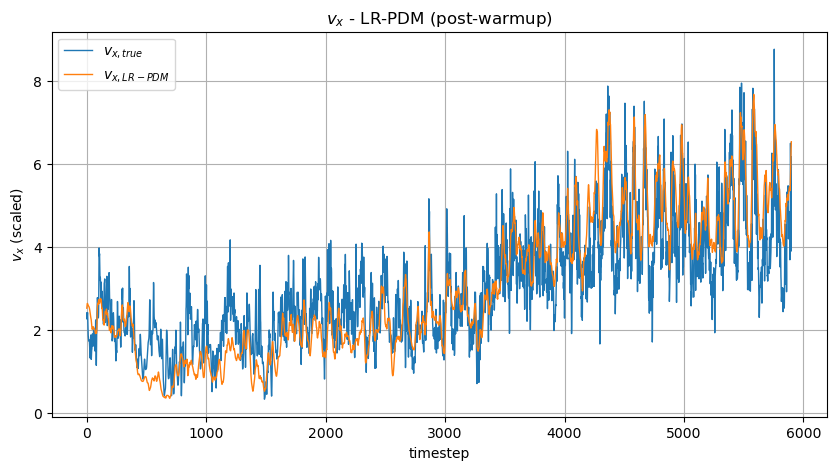

In [16]:
# --- Training ---
# We already have the scaled PDM feature from the c-PDM step: v_x_pdm_train_scaled
model_lr_pdm = LinearRegression()
model_lr_pdm.fit(X=v_x_pdm_train_scaled, y=y_true_train)

# --- Testing ---
# We already have the scaled test PDM feature: v_x_pdm_test_scaled
y_pred_lr_pdm_test = model_lr_pdm.predict(v_x_pdm_test_scaled)

# Calculate MSE on the test set minus the warmup period
mse_lr_pdm = mean_squared_error(y_true_test[n_warmup_test:], y_pred_lr_pdm_test[n_warmup_test:])
mses['LR-PDM'] = mse_lr_pdm
print(f"mse(LR-PDM) = {mse_lr_pdm}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_lr_pdm_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, LR-PDM}$",
    ],
    title="$v_x$ - LR-PDM (post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

---
## Section 2: Echo State Network + Ridge
---

Starting ESN hyperparameter search...
Fitting 2 folds for each of 2000 candidates, totalling 4000 fits

Best CV MSE: -0.67623
Best hyper‐parameters:
  • regressor__esn__input_scaling: 0.1107243222080376
  • regressor__esn__n_hidden_neurons: 189
  • regressor__esn__neuron_leak_rate: 0.7910495962024688
  • regressor__esn__regularization_scale: 2.3234989528649135
  • regressor__esn__w_spectral_radius: 0.7349334940101737

mse(esn-ridge) on test set = 0.6584686665125714


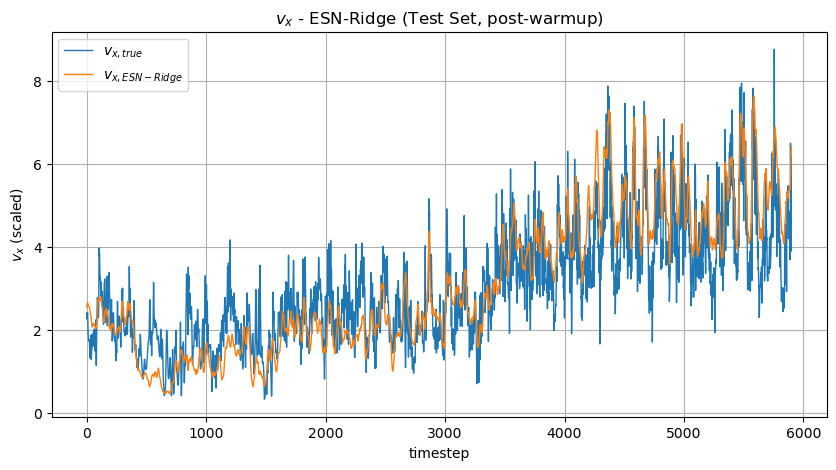

In [17]:
class ESNRidge(BaseEstimator, RegressorMixin):
    """
    A scikit-learn–compatible wrapper for an Echo State Network.
    """

    def __init__(
        self,
        n_hidden_neurons=200,
        neuron_leak_rate=0.3,
        w_spectral_radius=0.9,
        input_scaling=1.0,
        regularization_scale=1e-6,
        n_warmup_fit=100,
        n_warmup_pred=100,
        rpy_verbosity=0,
        random_state=None,
    ):
        self.n_hidden_neurons    = n_hidden_neurons
        self.neuron_leak_rate    = neuron_leak_rate
        self.w_spectral_radius   = w_spectral_radius
        self.input_scaling       = input_scaling
        self.regularization_scale= regularization_scale
        self.n_warmup_fit        = n_warmup_fit
        self.n_warmup_pred       = n_warmup_pred
        self.rpy_verbosity       = rpy_verbosity
        self.random_state        = random_state
        self.esn_                = None

    def fit(self, X, y):
        # 1) Set RPy verbosity & seed
        rpy.verbosity(self.rpy_verbosity)
        if self.random_state is not None:
            np.random.seed(self.random_state)
            rpy.set_seed(self.random_state)

        # 2) Build reservoir + readout
        reservoir = Reservoir(
            units=self.n_hidden_neurons,
            lr=self.neuron_leak_rate,
            sr=self.w_spectral_radius,
            input_scaling=self.input_scaling,
        )
        self._reservoir_name = reservoir.name

        readout = Ridge(ridge=self.regularization_scale)
        self._readout_name = readout.name

        inp = Input()
        self.esn_ = [inp, inp >> reservoir] >> readout

        # 3) Initialize with the first time-step
        self.esn_.initialize(X[0], y.reshape(-1, 1)[0])

        # 4) Create a reproducible initial state for warm-up
        self.init_state = np.random.uniform(
            -1, 1, size=(1, reservoir.output_dim)
        )

        # 5) Fit on the entire training series, with warm-up
        self.esn_ = self.esn_.fit(
            X,
            y.reshape(-1, 1),
            warmup=self.n_warmup_fit,
            from_state={reservoir.name: self.init_state},
        )
        return self

    def predict(self, X):
        y_pred_states = self.esn_.run(
            X,
            from_state={self._reservoir_name: self.init_state},
            return_states=[self._readout_name],
        )
        y_pred = y_pred_states[self._readout_name]
        return y_pred.ravel()

    def get_params(self, deep=True):
        return {
            "n_hidden_neurons":   self.n_hidden_neurons,
            "neuron_leak_rate":   self.neuron_leak_rate,
            "w_spectral_radius":  self.w_spectral_radius,
            "input_scaling":      self.input_scaling,
            "regularization_scale": self.regularization_scale,
            "n_warmup_fit":       self.n_warmup_fit,
            "n_warmup_pred":      self.n_warmup_pred,
            "rpy_verbosity":      self.rpy_verbosity,
            "random_state":       self.random_state,
        }

    def set_params(self, **params):
        for key, value in params.items():
            if not hasattr(self, key):
                raise ValueError(f"Unknown parameter '{key}' for ESNRegressor")
            setattr(self, key, value)
        return self
    
    def score(self, X, y_true):
        y_pred = self.predict(X)
        k = self.n_warmup_pred
        return -mean_squared_error(y_true[k:], y_pred[k:])

class GlobalStandardScaler(BaseEstimator, TransformerMixin):
    """
    Compute a single mean and standard deviation over all entries of X,
    then standardize every element in X by (X - mean) / std.
    """
    def __init__(self):
        self.mean_ = None
        self.scale_ = None

    def fit(self, X, y=None):
        flat = np.asarray(X).ravel()
        self.mean_ = flat.mean()
        self.scale_ = flat.std(ddof=0)
        if self.scale_ == 0:
            raise ValueError("GlobalStandardScaler: found zero variance in X")
        return self

    def transform(self, X):
        X = np.asarray(X)
        return (X - self.mean_) / self.scale_

    def inverse_transform(self, X):
        X = np.asarray(X)
        return X * self.scale_ + self.mean_

# 1) Define the scikit-learn pipeline
base_pipeline = Pipeline([
    ("scaler", GlobalStandardScaler()),
    ("esn", ESNRidge(
        n_warmup_fit=100,
        n_warmup_pred=n_warmup_test, # Use global warmup parameter
        rpy_verbosity=0,
        random_state=random_seed,
    ))
])
pipeline = TransformedTargetRegressor(
    regressor=base_pipeline,
    transformer=StandardScaler(),
)

# 2) Choose a time‐series CV splitter
tscv = TimeSeriesSplit(n_splits=2)

# 3) Define hyper‐parameter distributions
param_dist = {
    "regressor__esn__n_hidden_neurons":   randint(10, 500),
    "regressor__esn__neuron_leak_rate":   uniform(0.02, 1.0),
    "regressor__esn__w_spectral_radius":  loguniform(0.1, 10),
    "regressor__esn__input_scaling":      loguniform(0.1, 10.0),
    "regressor__esn__regularization_scale":loguniform(1e-6, 1e3),
}

# 4) Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=2000, # Reduced from 2000 for faster execution
    cv=tscv,
    scoring=None,  # uses regressor.score -> ESNRidge.score
    n_jobs=-1,
    verbose=4,
    random_state=random_seed,
)

# 5) Prepare data and fit
# X_train: Use unscaled phi data as the pipeline handles scaling
phi_y_1_train = phi_train_unscaled[:, i_y_1_y, i_y_1_z]
phi_y_2_train = phi_train_unscaled[:, i_y_2_y, i_y_2_z]
phi_center_train = phi_train_unscaled[:, i_y_center, i_z_center]
X_train = np.stack([phi_center_train, phi_y_1_train, phi_y_2_train], axis=1)

# y_train: Use unscaled true velocity data as the pipeline handles scaling
y_train_esn = y_true_train_unscaled[output_indices].ravel()

print("Starting ESN hyperparameter search...")
random_search.fit(X_train, y_train_esn)

# 6) Inspect results
print("\nBest CV MSE: {:.5f}".format(-random_search.best_score_))
print("Best hyper‐parameters:")
for k, v in random_search.best_params_.items():
    print(f"  • {k}: {v}")

# 7) Test with the best model
# X_test: Use unscaled phi data
phi_y_1_test = phi_test_unscaled[:, i_y_1_y, i_y_1_z]
phi_y_2_test = phi_test_unscaled[:, i_y_2_y, i_y_2_z]
phi_center_test = phi_test_unscaled[:, i_y_center, i_z_center]
X_test = np.stack([phi_center_test, phi_y_1_test, phi_y_2_test], axis=1)

# Predict (result is unscaled due to TransformedTargetRegressor)
best_model = random_search.best_estimator_
y_pred_esn_ridge_test_unscaled = best_model.predict(X_test)

# Scale prediction using the global scaler for fair comparison
y_pred_esn_ridge_test = ss_y_true.transform(y_pred_esn_ridge_test_unscaled.reshape(-1, 1))

# Calculate MSE using the globally scaled y_true_test and slicing off the warmup period
mse_esn_ridge = mean_squared_error(
    y_true_test[n_warmup_test:],
    y_pred_esn_ridge_test[n_warmup_test:],
)
mses['ESN-Ridge'] = mse_esn_ridge
print(f"\nmse(esn-ridge) on test set = {mse_esn_ridge}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_esn_ridge_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, ESN-Ridge}$",
    ],
    title="$v_x$ - ESN-Ridge (Test Set, post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

---
## Final Comparison
---

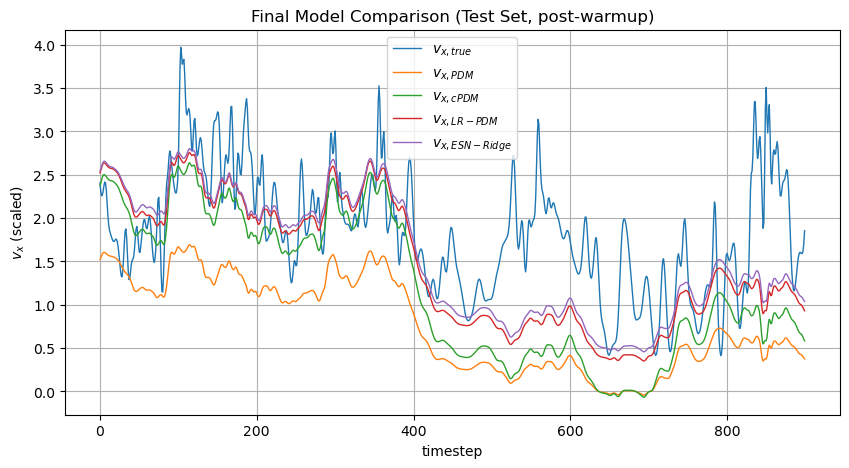

In [18]:
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:i_test_plot_end],
        y_pred_pdm_test[n_warmup_test:i_test_plot_end],
        y_pred_c_pdm_test[n_warmup_test:i_test_plot_end],
        y_pred_lr_pdm_test[n_warmup_test:i_test_plot_end],
        y_pred_esn_ridge_test[n_warmup_test:i_test_plot_end]
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, PDM}$",
        "$v_{x, cPDM}$",
        "$v_{x, LR-PDM}$",
        "$v_{x, ESN-Ridge}$",
    ],
    title="Final Model Comparison (Test Set, post-warmup)",
    xlabel="timestep",
    ylabel="$v_x$ (scaled)",
)

In [19]:
print("Mean Squared Errors for all methods (evaluated post-warmup):")
for method, error in sorted(mses.items(), key=lambda item: item[1]):
    print(f"  - {method}: {error:.6f}")

Mean Squared Errors for all methods (evaluated post-warmup):
  - General Benchmark: 0.025791
  - PDM Benchmark: 0.105402
  - ESN-Ridge: 0.658469
  - LR-PDM: 0.667876
  - c-PDM: 0.921059
  - PDM: 1.691828
